In [ ]:
# 安装所需的 Python 包
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy', 'matplotlib', 'scipy'])
print('所有依赖包安装完成!')

所有依赖包安装完成！


# 第 4 章 区间估计


> **本章导读**: 点估计给出了参数的最佳猜测值. 区间估计弥补了这一不足 -- 它给出一个覆盖参数真值的范围, 并控制这个范围覆盖真值的概率.


---


## 4.1 置信区间的基本概念


区间 [theta_L, theta_U] 满足 P(theta_L <= theta <= theta_U) >= 1-alpha, 则称其为置信水平为 1-alpha 的置信区间.


构造方法: 枢轴量法 -- 找函数 Q(X, theta) 其分布与 theta 无关.


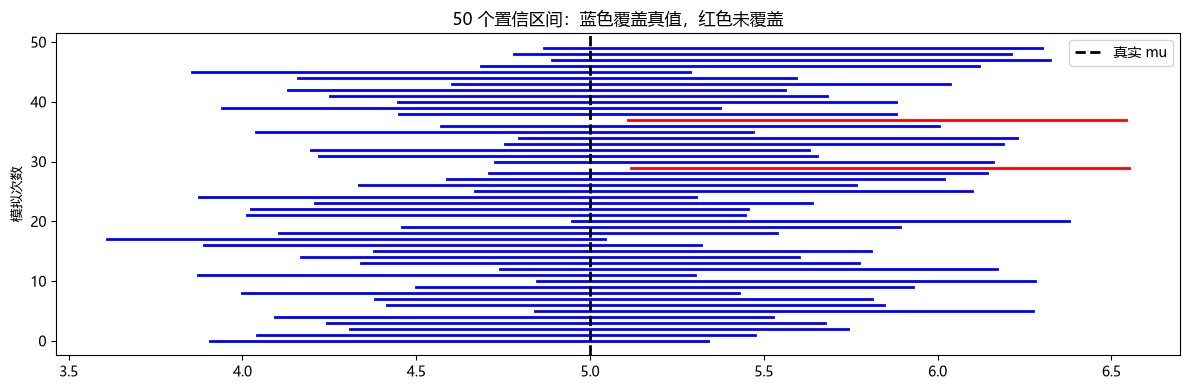

覆盖率: 48 / 50


In [ ]:
# 代码演示:置信区间的直观理解
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
true_mu=5
true_sigma=2
n=30
N_sim=50
alpha=0.05
from scipy.stats import norm
z=norm.ppf(1-alpha/2)

fig,ax=plt.subplots(figsize=(12,4))
covers=0
for i in range(N_sim):
    sample=np.random.normal(true_mu,true_sigma,n)
    xbar=np.mean(sample)
    ci_low=xbar-z*true_sigma/np.sqrt(n)
    ci_high=xbar+z*true_sigma/np.sqrt(n)
    cover=ci_low<=true_mu<=ci_high
    covers+=cover
    color='blue' if cover else 'red'
    ax.plot([ci_low,ci_high],[i,i],color=color,linewidth=2)
ax.axvline(true_mu,color='k',linestyle='--',linewidth=2,label='真实 mu')
ax.set_title('50 个置信区间:蓝色覆盖真值,红色未覆盖')
ax.set_ylabel('模拟次数')
ax.legend()
plt.tight_layout()
plt.show()
print('覆盖率:', covers, '/', N_sim)

## 4.2 正态总体的区间估计


### 4.2.1 sigma 已知时 mu 的置信区间


枢轴量: (X_bar-mu)/(sigma/sqrt(n)) ~ N(0,1)


区间: [X_bar - sigma/sqrt(n)*z_{alpha/2}, X_bar + sigma/sqrt(n)*z_{alpha/2}]


In [4]:
# 代码演示:正态总体 mu 的置信区间
import numpy as np
from scipy.stats import norm
np.random.seed(42)
true_mu,true_sigma=5,2
n=25
alpha=0.05
sample=np.random.normal(true_mu,true_sigma,n)
xbar=np.mean(sample)
z=norm.ppf(1-alpha/2)
ci=[xbar-z*true_sigma/np.sqrt(n), xbar+z*true_sigma/np.sqrt(n)]
print('sigma 已知时 mu 的 95% 置信区间:', [round(x,4) for x in ci])
print('真实 mu =', true_mu, '在区间内:', ci[0]<=true_mu<=ci[1])


sigma 已知时 mu 的 95% 置信区间: [np.float64(3.889), np.float64(5.457)]
真实 mu = 5 在区间内: True


### 4.2.2 sigma 未知时 mu 的置信区间


枢轴量: (X_bar-mu)/(S/sqrt(n)) ~ t(n-1)


In [5]:
# 代码演示:sigma 未知时 mu 的置信区间
import numpy as np
from scipy.stats import t as t_dist
np.random.seed(42)
true_mu,true_sigma=5,2
n=25
alpha=0.05
sample=np.random.normal(true_mu,true_sigma,n)
xbar=np.mean(sample)
s=np.std(sample,ddof=1)
tv=t_dist.ppf(1-alpha/2,n-1)
ci=[xbar-tv*s/np.sqrt(n), xbar+tv*s/np.sqrt(n)]
print('sigma 未知时 mu 的 95% 置信区间:', [round(x,4) for x in ci])
print('真实 mu =', true_mu, '在区间内:', ci[0]<=true_mu<=ci[1])


sigma 未知时 mu 的 95% 置信区间: [np.float64(3.8833), np.float64(5.4627)]
真实 mu = 5 在区间内: True


### 4.2.3-4.2.4 sigma^2 的置信区间


mu 已知: n*S0^2/sigma^2 ~ chi^2(n)


mu 未知: (n-1)*S^2/sigma^2 ~ chi^2(n-1)


In [6]:
# 代码演示:sigma^2 的置信区间
import numpy as np
from scipy.stats import chi2
np.random.seed(42)
true_mu,true_sigma=5,2
n=30
alpha=0.05
sample=np.random.normal(true_mu,true_sigma,n)
s2=np.var(sample,ddof=1)
c1=chi2.ppf(1-alpha/2,n-1)
c2=chi2.ppf(alpha/2,n-1)
ci=[(n-1)*s2/c1, (n-1)*s2/c2]
print('sigma^2 的 95% 置信区间:', [round(x,4) for x in ci])
print('真实 sigma^2 =', true_sigma**2, '在区间内:', ci[0]<=true_sigma**2<=ci[1])


sigma^2 的 95% 置信区间: [np.float64(2.055), np.float64(5.8554)]
真实 sigma^2 = 4 在区间内: True


## 4.3 其他分布的区间估计


### 4.3.1 指数分布 E(lambda) 的置信区间


枢轴量: 2n*X_bar/lambda ~ chi^2(2n)


In [7]:
# 代码演示:指数分布均值的置信区间
import numpy as np
from scipy.stats import chi2
np.random.seed(42)
true_lam=0.5
n=20
alpha=0.05
sample=np.random.exponential(1.0/true_lam,n)
xbar=np.mean(sample)
c1=chi2.ppf(1-alpha/2,2*n)
c2=chi2.ppf(alpha/2,2*n)
ci=[2*n*xbar/c1, 2*n*xbar/c2]
print('1/lambda 的 95% 置信区间:', [round(x,4) for x in ci])
print('真实 1/lambda =', round(1.0/true_lam,4))


1/lambda 的 95% 置信区间: [np.float64(1.2294), np.float64(2.9859)]
真实 1/lambda = 2.0


---
